<a href="https://colab.research.google.com/github/soumankumarpanja/Project_8th-semister/blob/main/Boosting.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Basic libraries for data manipulation and visualization
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Scikit-learn modules for data preprocessing, model selection, and evaluation
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    roc_curve
)

# Ensemble models from scikit-learn
from sklearn.ensemble import AdaBoostClassifier, GradientBoostingClassifier

# XGBoost classifier
from xgboost import XGBClassifier

# Import warnings and ignore warning messages for cleaner output
import warnings
warnings.filterwarnings('ignore')

here we import required library function.

In [ ]:
# Load the dataset
df = pd.read_csv('/content/Data File.csv')

# Display the first 5 rows of the DataFrame
display(df.head())

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,num
0,28,1,2,130,132,0,2,185,0,0.0,?,?,?,0
1,29,1,2,120,243,0,0,160,0,0.0,?,?,?,0
2,29,1,2,140,?,0,0,170,0,0.0,?,?,?,0
3,30,0,1,170,237,0,1,170,0,0.0,?,?,6,0
4,31,0,2,100,219,0,1,150,0,0.0,?,?,?,0


now in this step we loaded the data set from kaggle

In [ ]:
# Replace '?' with NaN for proper missing value detection
df_cleaned = df.replace('?', np.nan)

# --- Check for missing values ---
print("\n--- Missing Values ---")

# Calculate the number of missing values per column
missing_values = df_cleaned.isnull().sum()

# Calculate the percentage of missing values per column
missing_percentage = (df_cleaned.isnull().sum() / len(df_cleaned)) * 100

# Create a DataFrame to display missing values
missing_info = pd.DataFrame({
    'Missing Count': missing_values,
    'Missing Percentage': missing_percentage
})

# Filter to show only columns with missing values
missing_info = missing_info[missing_info['Missing Count'] > 0].sort_values(by='Missing Count', ascending=False)

# Display the missing values information
if not missing_info.empty:
    display(missing_info)
else:
    print("No missing values found in the dataset.")

# --- Check for duplicate rows ---
print("\n--- Duplicate Rows ---")

# Calculate the number of duplicate rows
duplicate_rows_count = df_cleaned.duplicated().sum()

if duplicate_rows_count > 0:
    print(f"Number of duplicate rows: {duplicate_rows_count}")
    # Remove duplicate rows
    df_cleaned = df_cleaned.drop_duplicates()
    print("Duplicate rows removed. New DataFrame shape:", df_cleaned.shape)
else:
    print("No duplicate rows found.")

# Update the original DataFrame reference to the cleaned one
df = df_cleaned.copy()

# Display the first few rows of the cleaned DataFrame to confirm changes
print("\n--- First 5 rows of the cleaned DataFrame ---")
display(df.head())


--- Missing Values ---


,Missing Count,Missing Percentage
ca,291,98.979592
thal,266,90.476190
slope,190,64.625850
chol,23,7.823129
fbs,8,2.721088
trestbps,1,0.340136
restecg,1,0.340136
thalach,1,0.340136
exang,1,0.340136



--- Duplicate Rows ---
Number of duplicate rows: 1
Duplicate rows removed. New DataFrame shape: (293, 14)

--- First 5 rows of the cleaned DataFrame ---


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,num
0,28,1,2,130,132,0,2,185,0,0.0,NaN,NaN,NaN,0
1,29,1,2,120,243,0,0,160,0,0.0,NaN,NaN,NaN,0
2,29,1,2,140,NaN,0,0,170,0,0.0,NaN,NaN,NaN,0
3,30,0,1,170,237,0,1,170,0,0.0,NaN,NaN,6,0
4,31,0,2,100,219,0,1,150,0,0.0,NaN,NaN,NaN,0


in this step we check the missing value

## Exploratory Data Analysis (EDA)

In [ ]:
# Display basic information about the dataset
print("\n--- Dataset Information ---")
df.info()

# Display descriptive statistics of the dataset
print("\n--- Descriptive Statistics ---")
display(df.describe())


--- Dataset Information ---
<class 'pandas.core.frame.DataFrame'>
Index: 293 entries, 0 to 293
Data columns (total 14 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   age         293 non-null    int64  
 1   sex         293 non-null    int64  
 2   cp          293 non-null    int64  
 3   trestbps    292 non-null    object 
 4   chol        271 non-null    object 
 5   fbs         285 non-null    object 
 6   restecg     292 non-null    object 
 7   thalach     292 non-null    object 
 8   exang       292 non-null    object 
 9   oldpeak     293 non-null    float64
 10  slope       104 non-null    object 
 11  ca          3 non-null      object 
 12  thal        28 non-null     object 
 13  num         293 non-null    int64  
dtypes: float64(1), int64(4), object(9)
memory usage: 34.3+ KB

--- Descriptive Statistics ---


,age,sex,cp,oldpeak,num
count,293.000000,293.000000,293.000000,293.000000,293.000000
mean,47.822526,0.726962,2.986348,0.588055,0.361775
std,7.824875,0.446282,0.965049,0.909554,0.481336
min,28.000000,0.000000,1.000000,0.000000,0.000000
25%,42.000000,0.000000,2.000000,0.000000,0.000000
50%,49.000000,1.000000,3.000000,0.000000,0.000000
75%,54.000000,1.000000,4.000000,1.000000,1.000000
max,66.000000,1.000000,4.000000,5.000000,1.000000


In [ ]:
# Convert columns to numeric, coercing errors will turn non-convertible values into NaN
# This is important as some columns might still be 'object' type due to initial '?' values
for col in ['trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'slope', 'ca', 'thal']:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')

print("Data types after numeric conversion:")
df.info()


Data types after numeric conversion:
<class 'pandas.core.frame.DataFrame'>
Index: 293 entries, 0 to 293
Data columns (total 14 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   age         293 non-null    int64  
 1   sex         293 non-null    int64  
 2   cp          293 non-null    int64  
 3   trestbps    292 non-null    float64
 4   chol        271 non-null    float64
 5   fbs         285 non-null    float64
 6   restecg     292 non-null    float64
 7   thalach     292 non-null    float64
 8   exang       292 non-null    float64
 9   oldpeak     293 non-null    float64
 10  slope       104 non-null    float64
 11  ca          3 non-null      float64
 12  thal        28 non-null     float64
 13  num         293 non-null    int64  
dtypes: float64(10), int64(4)
memory usage: 34.3 KB


In [ ]:
# Clean column names by stripping whitespace
df.columns = df.columns.str.strip()
print("Cleaned column names:")
print(df.columns)

Cleaned column names:
Index(['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach',
       'exang', 'oldpeak', 'slope', 'ca', 'thal', 'num'],
      dtype='object')


### Correlation Heatmap

Let's visualize the correlation matrix to understand relationships between numerical features. For this, we'll drop rows with NaNs temporarily to calculate the correlation accurately.

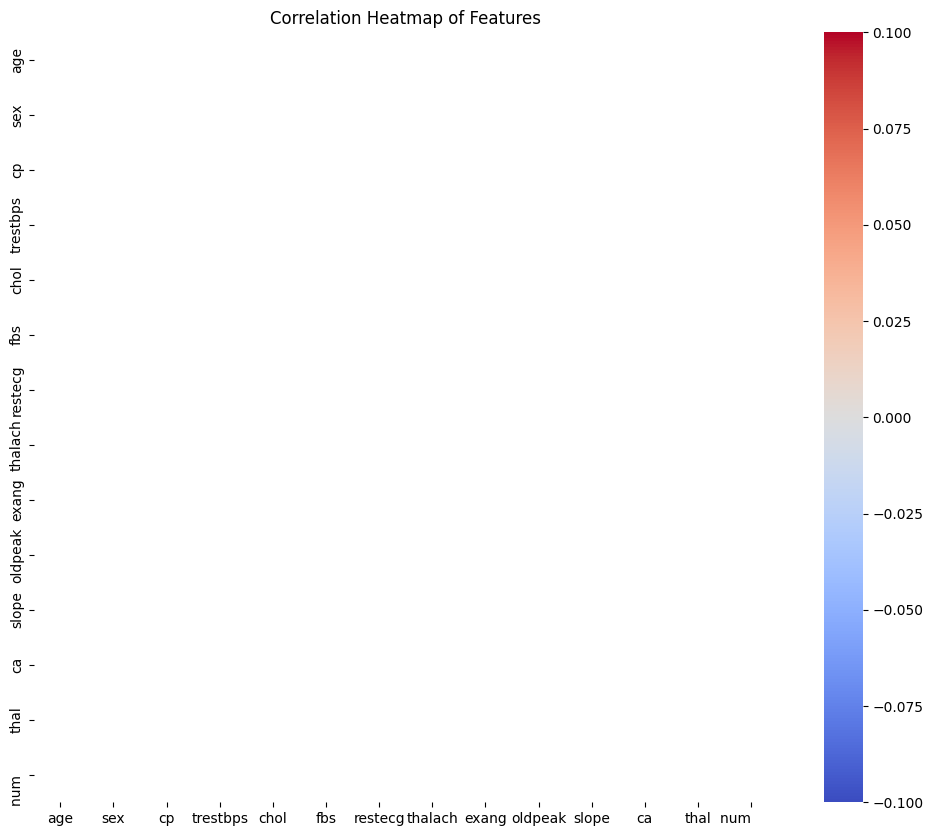

In [ ]:
# Calculate the correlation matrix, dropping rows with NaN for accurate calculation
correlation_matrix = df.dropna().corr()

plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap of Features')
plt.show()

### Histograms of Numerical Features

Histograms help visualize the distribution of individual numerical variables.

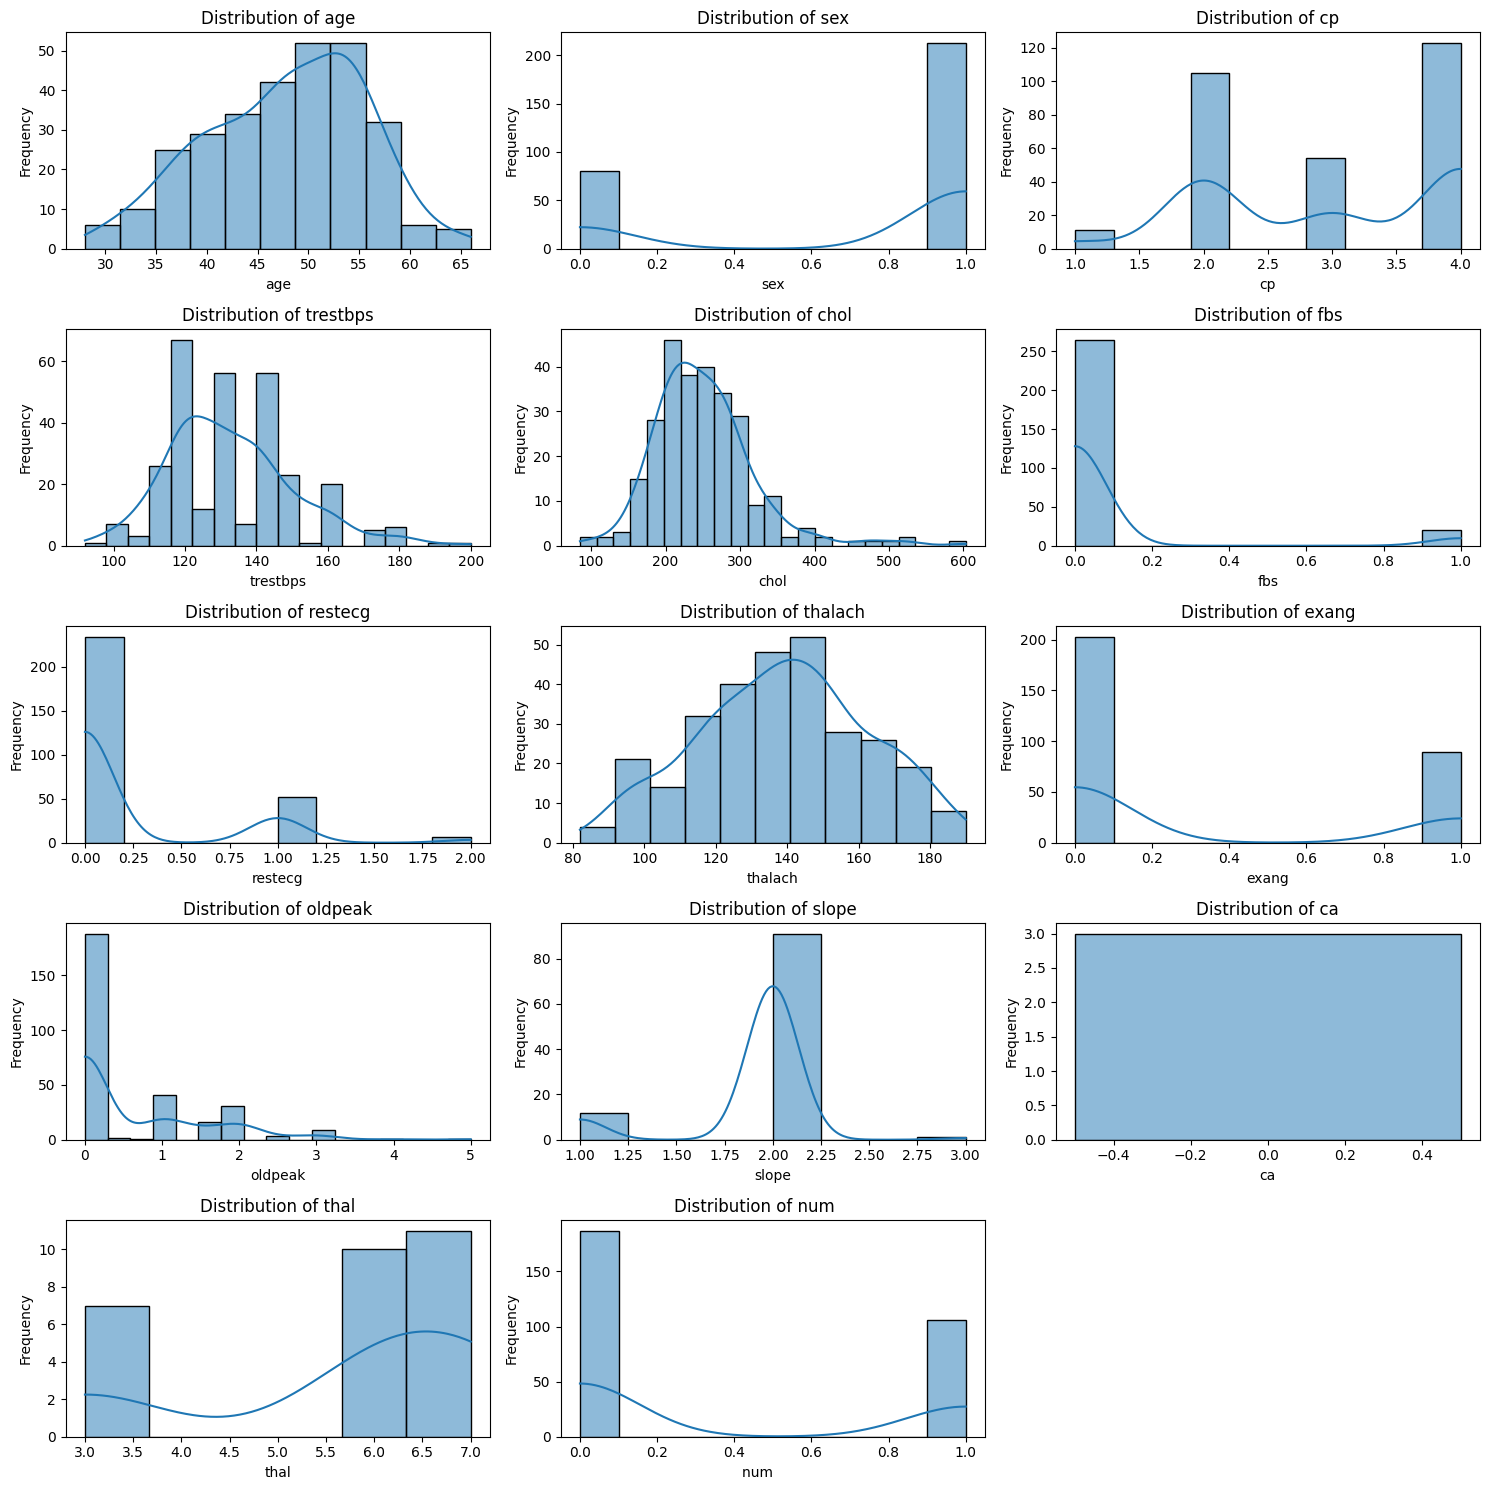

In [ ]:
# Select only numerical columns for histograms
numerical_cols = df.select_dtypes(include=np.number).columns.tolist()

# Exclude the target variable if it's numerical and we want to see features distribution
if 'num' in numerical_cols:
    numerical_cols.remove('num')

# Plotting histograms for numerical features
fig = plt.figure(figsize=(15, 15))
for i, col in enumerate(numerical_cols, 1):
    plt.subplot(5, 3, i) # Adjust grid size as needed
    sns.histplot(df[col].dropna(), kde=True)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

### Boxplots of Numerical Features

Boxplots are useful for identifying outliers and understanding the spread of numerical data.

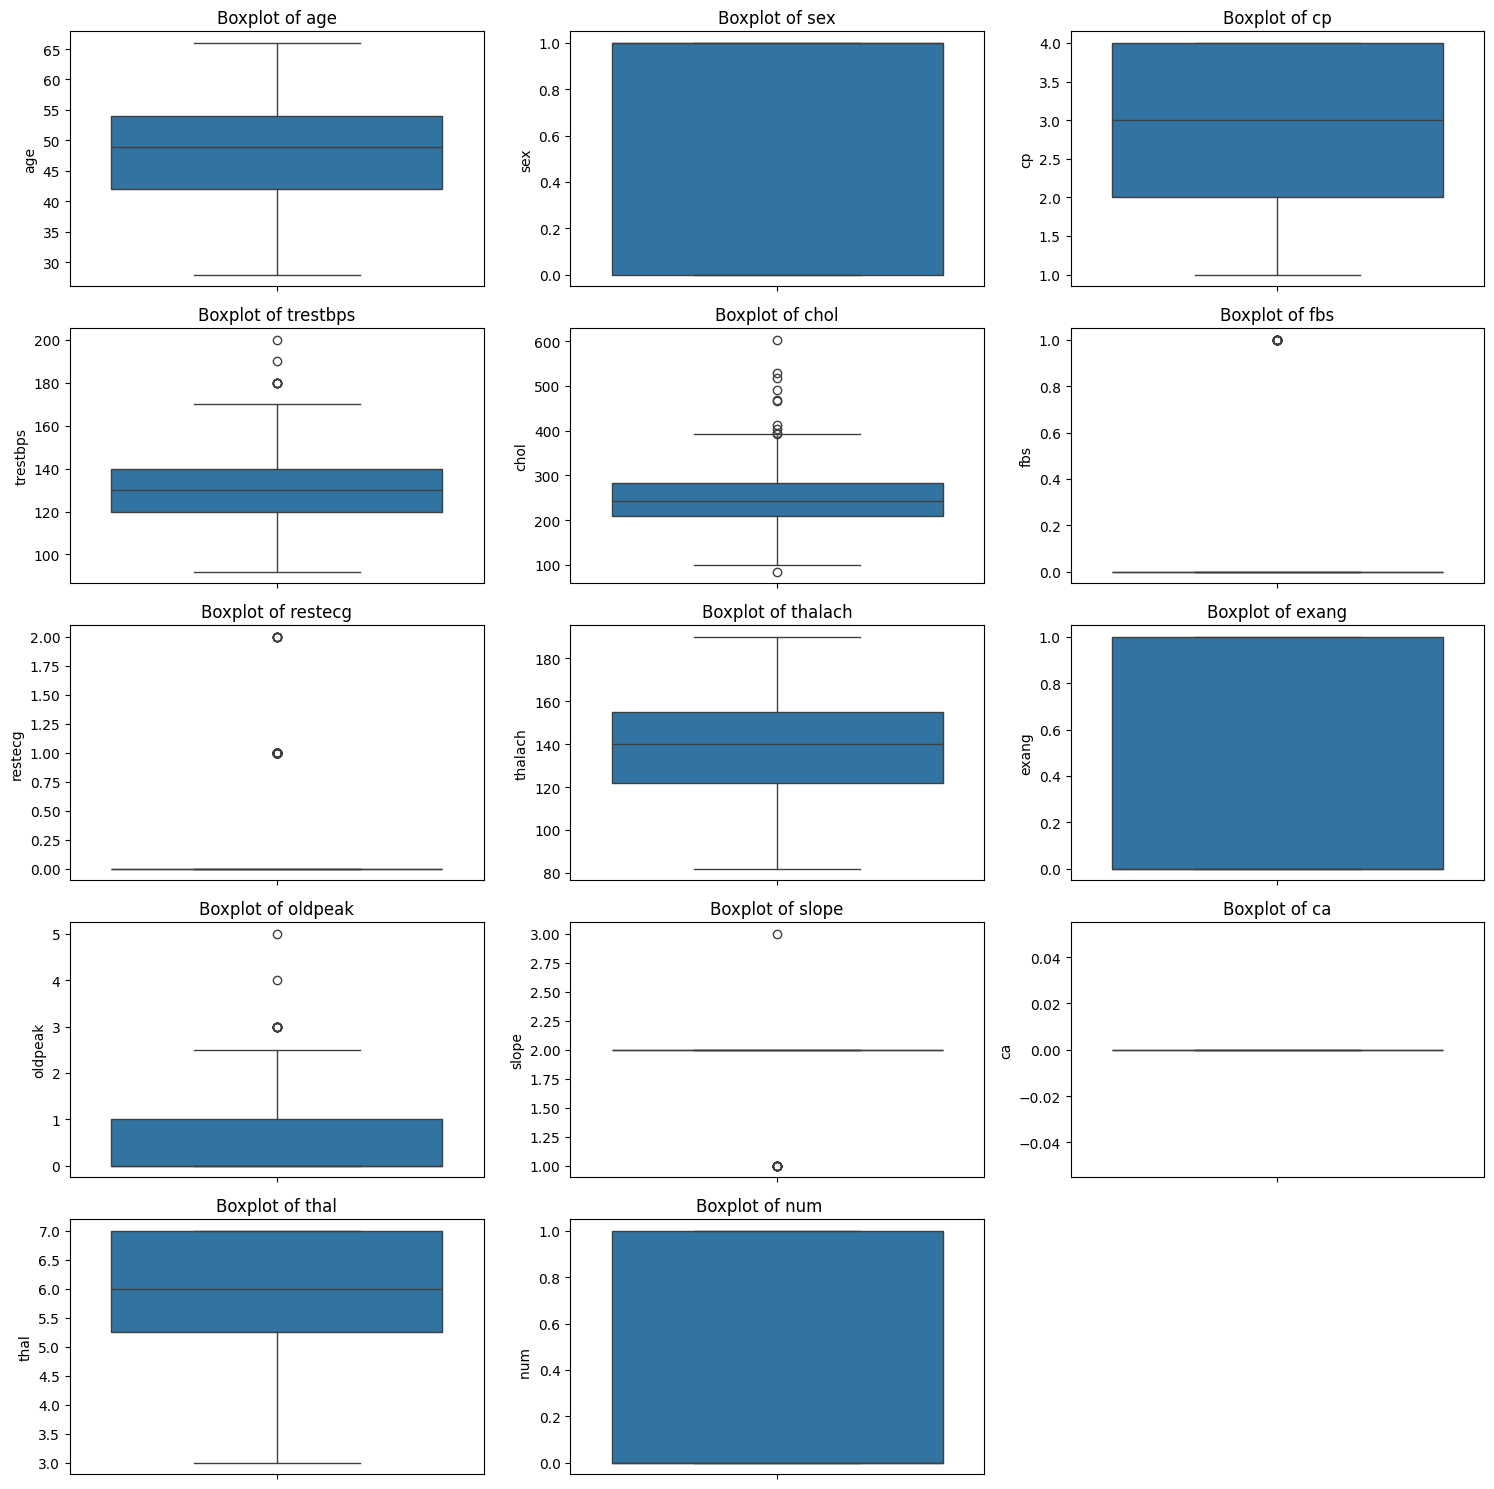

In [ ]:
# Plotting boxplots for numerical features
fig = plt.figure(figsize=(15, 15))
for i, col in enumerate(numerical_cols, 1):
    plt.subplot(5, 3, i) # Adjust grid size as needed
    sns.boxplot(y=df[col].dropna())
    plt.title(f'Boxplot of {col}')
    plt.ylabel(col)
plt.tight_layout()
plt.show()

### Countplot of Target Variable ('num')

This plot shows the distribution of the target variable, which is crucial for understanding class imbalance.

In [ ]:
plt.figure(figsize=(6, 5))
sns.countplot(x='num', data=df, palette='viridis')
plt.title('Distribution of Target Variable (num)')
plt.xlabel('Heart Disease (0 = No, 1 = Yes)')
plt.ylabel('Count')
plt.show()

ValueError: Could not interpret value `num` for `x`. An entry with this name does not appear in `data`.

<Figure size 600x500 with 0 Axes>

### Pairplot

A pairplot helps visualize pairwise relationships between variables. Due to potential high dimensionality and many missing values, we'll use a subset of key numerical columns and temporarily drop rows with NaNs for a clearer view.

In [ ]:
# Select a subset of numerical columns that are less sparse for the pairplot
# Exclude columns with a very high percentage of NaNs like 'ca', 'thal', 'slope'
# Also exclude 'num' from features as it's the target, but include it for hue

relevant_cols_for_pairplot = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak', 'num']

# Create a temporary DataFrame for the pairplot, dropping rows with NaNs in these relevant columns
df_pairplot = df[relevant_cols_for_pairplot].dropna()

# Generate the pairplot
sns.pairplot(df_pairplot, hue='num', palette='tab10', diag_kind='kde')
plt.suptitle('Pairplot of Selected Numerical Features by Target Variable', y=1.02) # Adjust suptitle position
plt.show()

KeyError: "['num'] not in index"

## Handling Missing Values

In [ ]:
# Identify columns with very high missing percentages from previous analysis
# ca: ~99%, thal: ~90%
high_missing_cols = ['ca', 'thal']

# Drop these columns from the DataFrame
df = df.drop(columns=high_missing_cols)
print(f"Columns {high_missing_cols} dropped due to high missing values.")
print(f"New DataFrame shape: {df.shape}")

Columns ['ca', 'thal'] dropped due to high missing values.
New DataFrame shape: (293, 12)


In [ ]:
# Identify remaining columns with missing values that are numerical
# From previous df.info() and missing_info:
# slope: ~64%, chol: ~8%, fbs: ~2.7%, trestbps: ~0.3%, restecg: ~0.3%, thalach: ~0.3%, exang: ~0.3%

# Columns to impute (these are all numerical/float type after conversion)
cols_to_impute_median = [
    'slope', 'chol', 'fbs', 'trestbps', 'restecg', 'thalach', 'exang'
]

print("\n--- Imputing Missing Values with Median ---")
for col in cols_to_impute_median:
    if col in df.columns:
        median_val = df[col].median()
        df[col].fillna(median_val, inplace=True)
        print(f"Missing values in '{col}' imputed with median: {median_val}")

# Verify that no missing values remain
print("\n--- Verification of Missing Values After Imputation ---")
missing_after_imputation = df.isnull().sum()
missing_after_imputation = missing_after_imputation[missing_after_imputation > 0]

if missing_after_imputation.empty:
    print("All missing values have been successfully handled.")
else:
    print("Remaining missing values:")
    display(missing_after_imputation)

# Display info and head of the cleaned DataFrame
print("\n--- DataFrame Info After Missing Value Handling ---")
df.info()
print("\n--- First 5 rows of DataFrame after Missing Value Handling ---")
display(df.head())


--- Imputing Missing Values with Median ---
Missing values in 'slope' imputed with median: 2.0
Missing values in 'chol' imputed with median: 243.0
Missing values in 'fbs' imputed with median: 0.0
Missing values in 'trestbps' imputed with median: 130.0
Missing values in 'restecg' imputed with median: 0.0
Missing values in 'thalach' imputed with median: 140.0
Missing values in 'exang' imputed with median: 0.0

--- Verification of Missing Values After Imputation ---
All missing values have been successfully handled.

--- DataFrame Info After Missing Value Handling ---
<class 'pandas.core.frame.DataFrame'>
Index: 293 entries, 0 to 293
Data columns (total 12 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       293 non-null    int64  
 1   sex       293 non-null    int64  
 2   cp        293 non-null    int64  
 3   trestbps  293 non-null    float64
 4   chol      293 non-null    float64
 5   fbs       293 non-null    float64
 6   restecg   

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,num
0,28,1,2,130.0,132.0,0.0,2.0,185.0,0.0,0.0,2.0,0
1,29,1,2,120.0,243.0,0.0,0.0,160.0,0.0,0.0,2.0,0
2,29,1,2,140.0,243.0,0.0,0.0,170.0,0.0,0.0,2.0,0
3,30,0,1,170.0,237.0,0.0,1.0,170.0,0.0,0.0,2.0,0
4,31,0,2,100.0,219.0,0.0,1.0,150.0,0.0,0.0,2.0,0


## Data Preparation: Feature Engineering, Scaling, and Splitting

In [ ]:
# 1. Separate features (X) and target (y)
X = df.drop('num', axis=1)
y = df['num']

print(f"Features (X) shape: {X.shape}")
print(f"Target (y) shape: {y.shape}")

Features (X) shape: (293, 11)
Target (y) shape: (293,)


In [ ]:
# 2. Identify numerical and categorical features

# Numerical features that need scaling
numerical_cols = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak', 'slope']

# Categorical features that need one-hot encoding (already imputed)
categorical_cols = ['cp', 'restecg']

# Binary categorical features that can be left as is or treated as numerical (0/1)
binary_cols = ['sex', 'fbs', 'exang']

# Ensure all identified columns exist in X
all_features = numerical_cols + categorical_cols + binary_cols
missing_in_X = [col for col in all_features if col not in X.columns]

if missing_in_X:
    print(f"Warning: The following identified features are not in X: {missing_in_X}")
    # Adjust lists to only include columns present in X
    numerical_cols = [col for col in numerical_cols if col in X.columns]
    categorical_cols = [col for col in categorical_cols if col in X.columns]
    binary_cols = [col for col in binary_cols if col in X.columns]

print(f"Numerical columns for scaling: {numerical_cols}")
print(f"Categorical columns for one-hot encoding: {categorical_cols}")
print(f"Binary columns (treated as is): {binary_cols}")

Numerical columns for scaling: ['age', 'trestbps', 'chol', 'thalach', 'oldpeak', 'slope']
Categorical columns for one-hot encoding: ['cp', 'restecg']
Binary columns (treated as is): ['sex', 'fbs', 'exang']


In [ ]:
# 3. Apply One-Hot Encoding to categorical features
# Use pd.get_dummies to convert categorical variables into dummy/indicator variables
X_encoded = pd.get_dummies(X, columns=categorical_cols, drop_first=True)

print("Features after One-Hot Encoding:")
display(X_encoded.head())

Features after One-Hot Encoding:


,age,sex,trestbps,chol,fbs,thalach,exang,oldpeak,slope,cp_2,cp_3,cp_4,restecg_1.0,restecg_2.0
0,28,1,130.0,132.0,0.0,185.0,0.0,0.0,2.0,True,False,False,False,True
1,29,1,120.0,243.0,0.0,160.0,0.0,0.0,2.0,True,False,False,False,False
2,29,1,140.0,243.0,0.0,170.0,0.0,0.0,2.0,True,False,False,False,False
3,30,0,170.0,237.0,0.0,170.0,0.0,0.0,2.0,False,False,False,True,False
4,31,0,100.0,219.0,0.0,150.0,0.0,0.0,2.0,True,False,False,True,False


In [ ]:
# 4. Apply StandardScaler to numerical features
scaler = StandardScaler()

# Fit and transform the numerical columns
X_encoded[numerical_cols] = scaler.fit_transform(X_encoded[numerical_cols])

print("Features after Scaling Numerical Columns:")
display(X_encoded.head())

Features after Scaling Numerical Columns:


,age,sex,trestbps,chol,fbs,thalach,exang,oldpeak,slope,cp_2,cp_3,cp_4,restecg_1.0,restecg_2.0
0,-2.537605,1,-0.151126,-1.819911,0.0,1.953350,0.0,-0.647637,0.181133,True,False,False,False,True
1,-2.409588,1,-0.721010,-0.111716,0.0,0.890327,0.0,-0.647637,0.181133,True,False,False,False,False
2,-2.409588,1,0.418757,-0.111716,0.0,1.315537,0.0,-0.647637,0.181133,True,False,False,False,False
3,-2.281572,0,2.128408,-0.204051,0.0,1.315537,0.0,-0.647637,0.181133,False,False,False,True,False
4,-2.153556,0,-1.860776,-0.481055,0.0,0.465118,0.0,-0.647637,0.181133,True,False,False,True,False


In [ ]:
# 5. Split the data into training and testing sets
# Using a 80/20 split, with a random state for reproducibility
X_train, X_test, y_train, y_test = train_test_split(X_encoded, y, test_size=0.2, random_state=42)

print(f"\nShape of X_train: {X_train.shape}")
print(f"Shape of X_test: {X_test.shape}")
print(f"Shape of y_train: {y_train.shape}")
print(f"Shape of y_test: {y_test.shape}")

print("\nData preparation complete. The data is now ready for model training.")


Shape of X_train: (234, 14)
Shape of X_test: (59, 14)
Shape of y_train: (234,)
Shape of y_test: (59,)

Data preparation complete. The data is now ready for model training.


now data preprocessing is complete in this step

now in the next step we train the model using AdaBoost

- random_state=42
- n_estimators=100

After training:

- Predict test data
- Calculate Accuracy
- Confusion Matrix
- Classification Report
- Precision
- Recall
- F1 Score
- ROC-AUC Score

all this work performe in this AdaBoost, it will print evalution metrics also

In [ ]:
print('--- AdaBoost Classifier ---')

# Initialize AdaBoost Classifier
adaboost_clf = AdaBoostClassifier(n_estimators=100, random_state=42)

# Train the model
adaboost_clf.fit(X_train, y_train)

# Predict on the test data
y_pred_adaboost = adaboost_clf.predict(X_test)
y_proba_adaboost = adaboost_clf.predict_proba(X_test)[:, 1]

# Calculate evaluation metrics
accuracy_adaboost = accuracy_score(y_test, y_pred_adaboost)
conf_matrix_adaboost = confusion_matrix(y_test, y_pred_adaboost)
class_report_adaboost = classification_report(y_test, y_pred_adaboost)
precision_adaboost = precision_score(y_test, y_pred_adaboost)
recall_adaboost = recall_score(y_test, y_pred_adaboost)
f1_adaboost = f1_score(y_test, y_pred_adaboost)
roc_auc_adaboost = roc_auc_score(y_test, y_proba_adaboost)

# Print evaluation metrics
print(f"Accuracy: {accuracy_adaboost:.4f}")
print("\nConfusion Matrix:")
print(conf_matrix_adaboost)
print("\nClassification Report:")
print(class_report_adaboost)
print(f"Precision: {precision_adaboost:.4f}")
print(f"Recall: {recall_adaboost:.4f}")
print(f"F1 Score: {f1_adaboost:.4f}")
print(f"ROC-AUC Score: {roc_auc_adaboost:.4f}")

--- AdaBoost Classifier ---
Accuracy: 0.8644

Confusion Matrix:
[[36  5]
 [ 3 15]]

Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.88      0.90        41
           1       0.75      0.83      0.79        18

    accuracy                           0.86        59
   macro avg       0.84      0.86      0.84        59
weighted avg       0.87      0.86      0.87        59

Precision: 0.7500
Recall: 0.8333
F1 Score: 0.7895
ROC-AUC Score: 0.9268


Now next step we train the a gradient Boosting Classifier

Use:

- random_state=42
- n_estimators=100
- learning_rate=0.1

Evaluate using:

- Accuracy
- Confusion Matrix
- Classification Report
- Precision
- Recall
- F1 Score
- ROC-AUC Score

Print all results clearly.


In [ ]:
print('\n--- Gradient Boosting Classifier ---')

# Initialize Gradient Boosting Classifier
gradient_boost_clf = GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, random_state=42)

# Train the model
gradient_boost_clf.fit(X_train, y_train)

# Predict on the test data
y_pred_gb = gradient_boost_clf.predict(X_test)
y_proba_gb = gradient_boost_clf.predict_proba(X_test)[:, 1]

# Calculate evaluation metrics
accuracy_gb = accuracy_score(y_test, y_pred_gb)
conf_matrix_gb = confusion_matrix(y_test, y_pred_gb)
class_report_gb = classification_report(y_test, y_pred_gb)
precision_gb = precision_score(y_test, y_pred_gb)
recall_gb = recall_score(y_test, y_pred_gb)
f1_gb = f1_score(y_test, y_pred_gb)
roc_auc_gb = roc_auc_score(y_test, y_proba_gb)

# Print evaluation metrics
print(f"Accuracy: {accuracy_gb:.4f}")
print("\nConfusion Matrix:")
print(conf_matrix_gb)
print("\nClassification Report:")
print(class_report_gb)
print(f"Precision: {precision_gb:.4f}")
print(f"Recall: {recall_gb:.4f}")
print(f"F1 Score: {f1_gb:.4f}")
print(f"ROC-AUC Score: {roc_auc_gb:.4f}")


--- Gradient Boosting Classifier ---
Accuracy: 0.8475

Confusion Matrix:
[[37  4]
 [ 5 13]]

Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.90      0.89        41
           1       0.76      0.72      0.74        18

    accuracy                           0.85        59
   macro avg       0.82      0.81      0.82        59
weighted avg       0.85      0.85      0.85        59

Precision: 0.7647
Recall: 0.7222
F1 Score: 0.7429
ROC-AUC Score: 0.9011


now in ths step we train the XGB boost
- random_state=42
- n_estimators=100
- learning_rate=0.1
- max_depth=3
- eval_metric='logloss'

After training, calculate:

- Accuracy
- Confusion Matrix
- Classification Report
- Precision
- Recall
- F1 Score
- ROC-AUC Score

Print all results clearly.

In [ ]:
print('\n--- XGBoost Classifier (Updated) ---')

# Initialize XGBoost Classifier with updated parameters
xgboost_clf = XGBClassifier(
    n_estimators=200, # Updated from 100
    learning_rate=0.05, # Updated from 0.1
    max_depth=4, # Updated from 3
    eval_metric='logloss',
    use_label_encoder=False, # Suppress the warning for future versions
    random_state=42
)

# Train the model
xgboost_clf.fit(X_train, y_train)

# Predict on the test data
y_pred_xgb = xgboost_clf.predict(X_test)
y_proba_xgb = xgboost_clf.predict_proba(X_test)[:, 1]

# Calculate evaluation metrics
accuracy_xgb = accuracy_score(y_test, y_pred_xgb)
conf_matrix_xgb = confusion_matrix(y_test, y_pred_xgb)
class_report_xgb = classification_report(y_test, y_pred_xgb)
precision_xgb = precision_score(y_test, y_pred_xgb)
recall_xgb = recall_score(y_test, y_pred_xgb)
f1_xgb = f1_score(y_test, y_pred_xgb)
roc_auc_xgb = roc_auc_score(y_test, y_proba_xgb)

# Print evaluation metrics
print(f"Accuracy: {accuracy_xgb:.4f}")
print("\nConfusion Matrix:")
print(conf_matrix_xgb)
print("\nClassification Report:")
print(class_report_xgb)
print(f"Precision: {precision_xgb:.4f}")
print(f"Recall: {recall_xgb:.4f}")
print(f"F1 Score: {f1_xgb:.4f}")
print(f"ROC-AUC Score: {roc_auc_xgb:.4f}")


--- XGBoost Classifier (Updated) ---
Accuracy: 0.8475

Confusion Matrix:
[[35  6]
 [ 3 15]]

Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.85      0.89        41
           1       0.71      0.83      0.77        18

    accuracy                           0.85        59
   macro avg       0.82      0.84      0.83        59
weighted avg       0.86      0.85      0.85        59

Precision: 0.7143
Recall: 0.8333
F1 Score: 0.7692
ROC-AUC Score: 0.9295


Now in this step we show here all three confusion matrix clearly

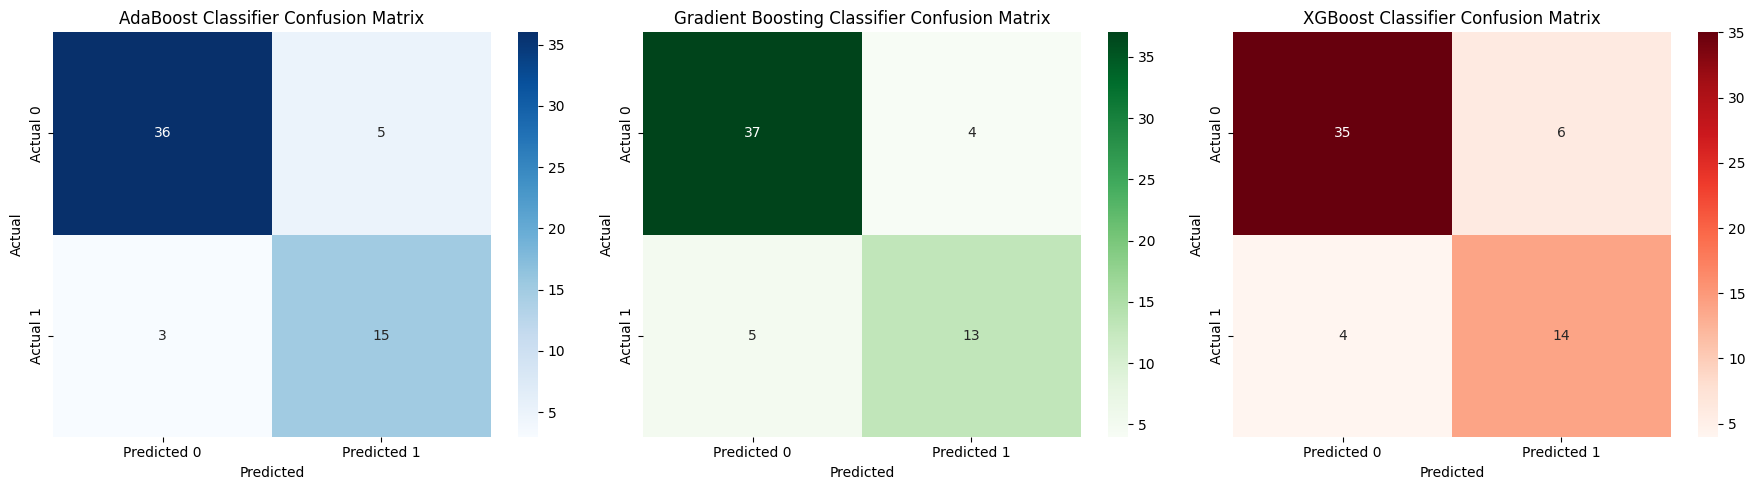

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot for AdaBoost Classifier
sns.heatmap(conf_matrix_adaboost, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Predicted 0', 'Predicted 1'],
            yticklabels=['Actual 0', 'Actual 1'])
axes[0].set_title('AdaBoost Classifier Confusion Matrix')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

# Plot for Gradient Boosting Classifier
sns.heatmap(conf_matrix_gb, annot=True, fmt='d', cmap='Greens', ax=axes[1],
            xticklabels=['Predicted 0', 'Predicted 1'],
            yticklabels=['Actual 0', 'Actual 1'])
axes[1].set_title('Gradient Boosting Classifier Confusion Matrix')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')

# Plot for XGBoost Classifier
sns.heatmap(conf_matrix_xgb, annot=True, fmt='d', cmap='Reds', ax=axes[2],
            xticklabels=['Predicted 0', 'Predicted 1'],
            yticklabels=['Actual 0', 'Actual 1'])
axes[2].set_title('XGBoost Classifier Confusion Matrix')
axes[2].set_xlabel('Predicted')
axes[2].set_ylabel('Actual')

plt.tight_layout()
plt.show()

here we draw the ROC curve based on this code

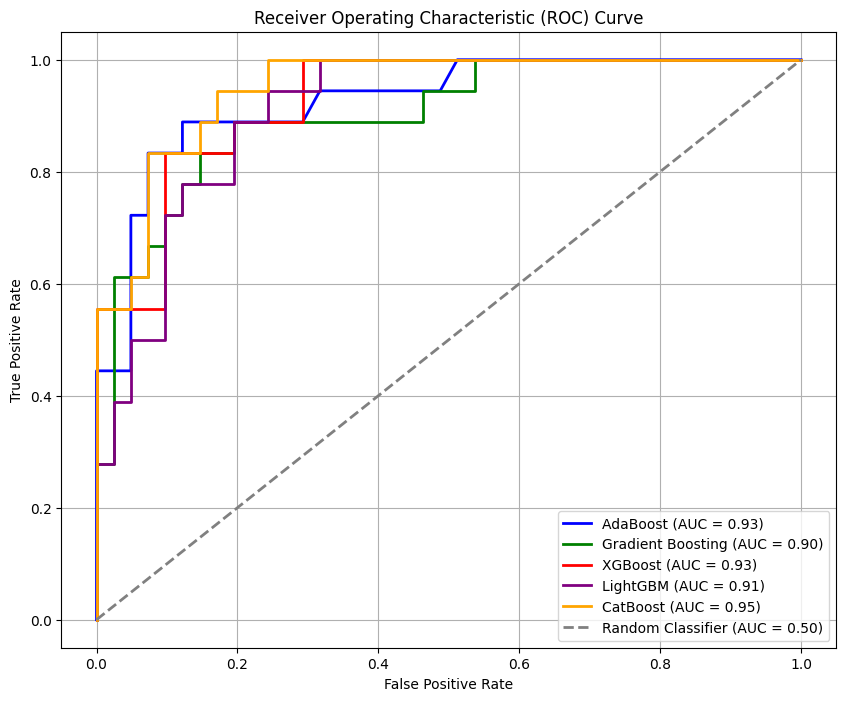

In [ ]:
plt.figure(figsize=(10, 8))

# ROC Curve for AdaBoost
fpr_adaboost, tpr_adaboost, _ = roc_curve(y_test, y_proba_adaboost)
plt.plot(fpr_adaboost, tpr_adaboost, color='blue', lw=2, label=f'AdaBoost (AUC = {roc_auc_adaboost:.2f})')

# ROC Curve for Gradient Boosting
fpr_gb, tpr_gb, _ = roc_curve(y_test, y_proba_gb)
plt.plot(fpr_gb, tpr_gb, color='green', lw=2, label=f'Gradient Boosting (AUC = {roc_auc_gb:.2f})')

# ROC Curve for XGBoost
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, y_proba_xgb)
plt.plot(fpr_xgb, tpr_xgb, color='red', lw=2, label=f'XGBoost (AUC = {roc_auc_xgb:.2f})')

# ROC Curve for LightGBM
fpr_lgbm, tpr_lgbm, _ = roc_curve(y_test, y_proba_lgbm)
plt.plot(fpr_lgbm, tpr_lgbm, color='purple', lw=2, label=f'LightGBM (AUC = {roc_auc_lgbm:.2f})')

# ROC Curve for CatBoost
fpr_catboost, tpr_catboost, _ = roc_curve(y_test, y_proba_catboost)
plt.plot(fpr_catboost, tpr_catboost, color='orange', lw=2, label=f'CatBoost (AUC = {roc_auc_catboost:.2f})')

# Plotting the random classifier line
plt.plot([0, 1], [0, 1], color='gray', lw=2, linestyle='--', label='Random Classifier (AUC = 0.50)')

# Adding labels, title, and legend
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

now in this step we compare    Accuracy - Precision - Recall - F1 Score - ROC-AUC Score

## Model Comparison

In [ ]:
comparison_df = pd.DataFrame({
    'Model': ['AdaBoost', 'Gradient Boosting', 'XGBoost', 'LightGBM', 'CatBoost'],
    'Accuracy': [accuracy_adaboost, accuracy_gb, accuracy_xgb, accuracy_lgbm, accuracy_catboost],
    'Precision': [precision_adaboost, precision_gb, precision_xgb, precision_lgbm, precision_catboost],
    'Recall': [recall_adaboost, recall_gb, recall_xgb, recall_lgbm, recall_catboost],
    'F1 Score': [f1_adaboost, f1_gb, f1_xgb, f1_lgbm, f1_catboost],
    'ROC-AUC Score': [roc_auc_adaboost, roc_auc_gb, roc_auc_xgb, roc_auc_lgbm, roc_auc_catboost]
})

# Sort by Accuracy in descending order
comparison_df_sorted = comparison_df.sort_values(by='Accuracy', ascending=False).reset_index(drop=True)

# Highlight the best performing model (first row after sorting by accuracy)
def highlight_best(s):
    is_max = s == s.max()
    return ['background-color: yellow' if v else '' for v in is_max]

display(comparison_df_sorted.style.apply(highlight_best, subset=['Accuracy', 'Precision', 'Recall', 'F1 Score', 'ROC-AUC Score']))

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC Score
0,CatBoost,0.881356,0.823529,0.777778,0.800000,0.949864
1,AdaBoost,0.864407,0.750000,0.833333,0.789474,0.926829
2,Gradient Boosting,0.847458,0.764706,0.722222,0.742857,0.901084
3,XGBoost,0.847458,0.714286,0.833333,0.769231,0.929539
4,LightGBM,0.813559,0.652174,0.833333,0.731707,0.910569


now in this step we save the best accuracy model

## Save and Load the Best Performing Model

In [ ]:
import joblib

# Assuming adaboost_clf is the best model based on accuracy from the comparison
best_model = adaboost_clf

# Define the filename
model_filename = 'best_boosting_model.pkl'

# Save the model
joblib.dump(best_model, model_filename)
print(f"Best model saved as {model_filename}")

Best model saved as best_boosting_model.pkl


### Load the saved model and make predictions

In [ ]:
import joblib

# Load the model from the file
loaded_model = joblib.load('best_boosting_model.pkl')
print("Model loaded successfully!")

# Make predictions on new data (using X_test as an example for demonstration)
predictions_on_new_data = loaded_model.predict(X_test)
probabilities_on_new_data = loaded_model.predict_proba(X_test)[:, 1]

print("\nExample predictions on X_test (first 5 samples):")
print(predictions_on_new_data[:5])
print("\nExample probabilities on X_test (first 5 samples):")
print(probabilities_on_new_data[:5])

# Optionally, evaluate the loaded model's performance on X_test to ensure consistency
loaded_model_accuracy = accuracy_score(y_test, predictions_on_new_data)
print(f"\nAccuracy of the loaded model on X_test: {loaded_model_accuracy:.4f}")

Model loaded successfully!

Example predictions on X_test (first 5 samples):
[0 1 0 0 0]

Example probabilities on X_test (first 5 samples):
[0.4688542  0.572505   0.3577466  0.4842757  0.34212233]

Accuracy of the loaded model on X_test: 0.8644


**Now we start the next ensemble model **2**






IN THE FIRST ENSEMBLE MODEL ALL  IS COMPLETE HERE

now in this next step atfirst we do the preprocessing

After thr preprocessing we train the data using LightGBM


Use:

random_state=42

n_estimators=200

learning_rate=0.05

max_depth=4

After training evaluate using:

Accuracy

Precision

Recall

F1 Score

ROC AUC

Confusion Matrix

Classification Report

Print all metrics.

## LightGBM Classifier Training and Evaluation

In [ ]:
# Import LightGBM Classifier
from lightgbm import LGBMClassifier

print('\n--- LightGBM Classifier ---')

# Initialize LightGBM Classifier
lgbm_clf = LGBMClassifier(
    random_state=42,
    n_estimators=200,
    learning_rate=0.05,
    max_depth=4
)

# Train the model
lgbm_clf.fit(X_train, y_train)

# Predict on the test data
y_pred_lgbm = lgbm_clf.predict(X_test)
y_proba_lgbm = lgbm_clf.predict_proba(X_test)[:, 1]

# Calculate evaluation metrics
accuracy_lgbm = accuracy_score(y_test, y_pred_lgbm)
conf_matrix_lgbm = confusion_matrix(y_test, y_pred_lgbm)
class_report_lgbm = classification_report(y_test, y_pred_lgbm)
precision_lgbm = precision_score(y_test, y_pred_lgbm)
recall_lgbm = recall_score(y_test, y_pred_lgbm)
f1_lgbm = f1_score(y_test, y_pred_lgbm)
roc_auc_lgbm = roc_auc_score(y_test, y_proba_lgbm)

# Print evaluation metrics
print(f"Accuracy: {accuracy_lgbm:.4f}")
print("\nConfusion Matrix:")
print(conf_matrix_lgbm)
print("\nClassification Report:")
print(class_report_lgbm)
print(f"Precision: {precision_lgbm:.4f}")
print(f"Recall: {recall_lgbm:.4f}")
print(f"F1 Score: {f1_lgbm:.4f}")
print(f"ROC-AUC Score: {roc_auc_lgbm:.4f}")


--- LightGBM Classifier ---
[LightGBM] [Info] Number of positive: 88, number of negative: 146
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000354 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 171
[LightGBM] [Info] Number of data points in the train set: 234, number of used features: 11
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.376068 -> initscore=-0.506270
[LightGBM] [Info] Start training from score -0.506270
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with po

## CatBoost Classifier Training and Evaluation

In [ ]:
!pip install catboost

In [ ]:
# Import CatBoost Classifier
from catboost import CatBoostClassifier

print('\n--- CatBoost Classifier ---')

# Initialize CatBoost Classifier
catboost_clf = CatBoostClassifier(
    iterations=200,
    learning_rate=0.05,
    depth=6,
    random_state=42,
    verbose=0, # Suppress verbose output during training
    eval_metric='AUC' # Specify AUC as evaluation metric for consistency
)

# Train the model
catboost_clf.fit(X_train, y_train)

# Predict on the test data
y_pred_catboost = catboost_clf.predict(X_test)
y_proba_catboost = catboost_clf.predict_proba(X_test)[:, 1]

# Calculate evaluation metrics
accuracy_catboost = accuracy_score(y_test, y_pred_catboost)
conf_matrix_catboost = confusion_matrix(y_test, y_pred_catboost)
class_report_catboost = classification_report(y_test, y_pred_catboost)
precision_catboost = precision_score(y_test, y_pred_catboost)
recall_catboost = recall_score(y_test, y_pred_catboost)
f1_catboost = f1_score(y_test, y_pred_catboost)
roc_auc_catboost = roc_auc_score(y_test, y_proba_catboost)

# Print evaluation metrics
print(f"Accuracy: {accuracy_catboost:.4f}")
print("\nConfusion Matrix:")
print(conf_matrix_catboost)
print("\nClassification Report:")
print(class_report_catboost)
print(f"Precision: {precision_catboost:.4f}")
print(f"Recall: {recall_catboost:.4f}")
print(f"F1 Score: {f1_catboost:.4f}")
print(f"ROC-AUC Score: {roc_auc_catboost:.4f}")


--- CatBoost Classifier ---
Accuracy: 0.8814

Confusion Matrix:
[[38  3]
 [ 4 14]]

Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.93      0.92        41
           1       0.82      0.78      0.80        18

    accuracy                           0.88        59
   macro avg       0.86      0.85      0.86        59
weighted avg       0.88      0.88      0.88        59

Precision: 0.8235
Recall: 0.7778
F1 Score: 0.8000
ROC-AUC Score: 0.9499
